Atividade 5: Realizar uma pré-distorção
a. Partindo dos resultados da Atividade 3, o PA a ser linearizado é um modelo MP (ou seja, seu PA será o modelo MP treinado na Atividade 3). 
b. Treinar um DPD. Como modelo de DPD, usar o MP (ou seja, PA e DPD terão a mesma equação, porém coeficientes diferentes). Para treinar o DPD, primeiro coletar dados na entrada e na saída do MP que modelo o PA (ou seja, passar o in_extraction no MP e medir a saída estimada). No DPD, trocam-se os papeís de entrada e saída (ou seja, saída do PA é entrada do DPD e vice-versa)
c. Obter a seguinte cascata (modelo MP do DPD +  modelo MP do PA):
c1. O sinal de entrada, a ser aplicado no modelo MP do DPD  treinado no item b. é ganho*in_validation. O ganho é um número fixo e evita extrapolação do modelo. Obtê-lo usando ganho= abs(out_esimado_PA)/abs(in).  
c2. O sinal estimado na saída do modelo MP do DPD  agora deve ser aplicado como entrada do modelo MP do PA. 
d. Para validar a pré-distorção, comparar a entrada da cascata com a saída da cascata.


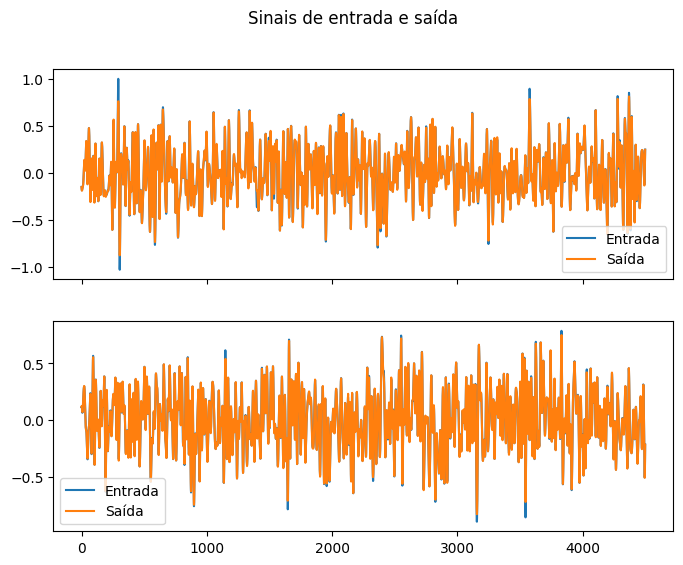

In [1]:
from functions import *

mat = loadmat('data_LDMOS_formatted_4500p.mat')

in_data_ext = mat['in_extraction']
out_data_ext = mat['out_extraction']
in_data_val = mat['in_validation']
out_data_val = mat['out_validation']


lista = [in_data_ext, out_data_ext, in_data_val, out_data_val]

modulos = []
for i in lista:
    modulos.append(max(i.imag))
    modulos.append(max(i.real))

maior_modulo = max(modulos)

in_ext_norm  = in_data_ext / maior_modulo
out_ext_norm = out_data_ext / maior_modulo
in_val_norm  = in_data_val / maior_modulo
out_val_norm = out_data_val / maior_modulo

plot_signals(in_ext_norm,out_ext_norm, in_val_norm,out_val_norm)

In [2]:
def bloco_memoria_mp(x_delay, coef_m, ordem):
    """
    Implementa o bloco:
        sum_{p=1}^P b_{p,m} * x(n-m) * |x(n-m)|^(2*(p-1))

    x_delay : x(n-m) (vetor complexo)
    coef_m  : coeficientes complexos desse atraso (tamanho = ordem)
    ordem   : ordem do polinômio
    """
    y_m = np.zeros_like(x_delay, dtype=complex)

    for p in range(1, ordem + 1):
        y_m += coef_m[p-1] * x_delay * np.abs(x_delay)**(2*(p-1))

    return y_m


def mp_model(x_in, coef, ordem, memoria):
    """
    Modelo Memory Polynomial estruturado por blocos

    coef : vetor complexo organizado como:
           [b_{1,0}, ..., b_{P,0},
            b_{1,1}, ..., b_{P,1},
            ...
            b_{1,M}, ..., b_{P,M}]
    """
    x_in = x_in.flatten()
    N = len(x_in)
    y_est = np.zeros(N, dtype=complex).flatten()

    idx = 0
    for m in range(memoria + 1):
        # Atraso
        x_delay = np.roll(x_in, m)

        # Coeficientes desse bloco de memória
        coef_m = coef[idx:idx + ordem]
        idx += ordem

        # Bloco do somatório (figura que você mostrou)
        y_est += bloco_memoria_mp(x_delay, coef_m, ordem)

    return y_est

def erro_mp_complex_blocos(params, x_in, y_out, ordem, memoria):
    """
    Erro do modelo MP estruturado por blocos
    """
    C = len(params) // 2
    coef = params[:C] + 1j * params[C:]

    y_est = mp_model(x_in, coef, ordem, memoria)
    erro = y_out - y_est

    return np.abs(erro) 


In [3]:
M = 2
P = 5
from scipy.optimize import least_squares


def extract_coefficients(in_ext,out_ext,M, P):
    in_ext = in_ext.flatten()
    out_ext = out_ext.flatten()
    num_coef = P * (M + 1)
    x0 = np.zeros(2*num_coef)
    
    res = least_squares(
    erro_mp_complex_blocos,
    x0,
    args=(in_ext, out_ext, P, M),
    verbose=2
    )

    coefficients = res.x[:num_coef] + 1j*res.x[num_coef:]
    print("Coeficientes complexos otimizados:", coefficients)
    
    return coefficients   
# calculo dos coeficientes do modelo do PA
coefficients_PA_float = extract_coefficients(in_data_ext,out_data_ext,M, P)
# Saida estimada do modelo do PA
predicted_ext_PA = mp_model(in_data_ext, coefficients_PA_float, P, M)


# Calculo do modelo do pre-distorcedor
coefficients_DPD_float = extract_coefficients(predicted_ext_PA,in_data_ext, M, P)
# Saida estimada do modelo do predistorcedor
predicted_ext_pre = mp_model(predicted_ext_PA.flatten(), coefficients_DPD_float, P, M)



   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         2.3106e+02                                    4.63e+02    
       1              2         5.5402e+00      2.26e+02       1.00e+00       6.86e+01    
       2              3         3.4597e-01      5.19e+00       2.00e+00       1.36e+01    
       3              4         6.7394e-02      2.79e-01       4.00e+00       2.16e+00    
       4              5         5.3629e-02      1.38e-02       8.00e+00       1.76e+00    
       5              7         5.2989e-02      6.41e-04       1.98e+00       1.72e+00    
       6              9         5.2552e-02      4.37e-04       1.24e-01       1.66e+00    
       7             10         5.1320e-02      1.23e-03       3.10e-02       1.88e+00    
       8             11         4.6810e-02      4.51e-03       7.75e-03       1.39e+00    
       9             12         4.6608e-02      2.02e-04       7.75e-03       1.53e+00    

In [4]:
# saida estimada da cascata
predicted_val_PA = mp_model(in_data_val, coefficients_PA_float, P, M)

predicted_val_DPD = mp_model(predicted_val_PA, coefficients_DPD_float, P, M)

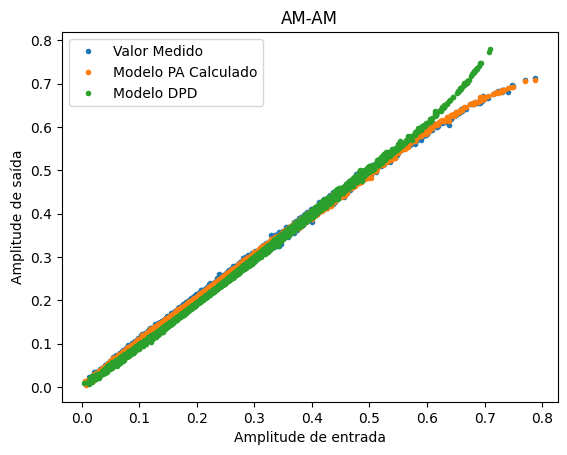

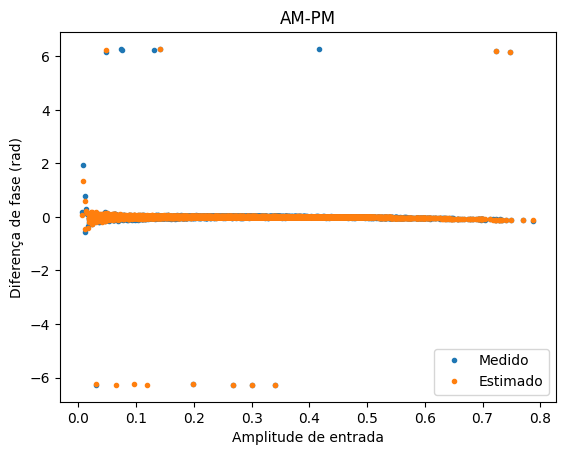

In [5]:
# Gráficos AM-AM e AM-PM
plt.figure()
plt.plot(np.abs(in_data_val), np.abs(out_data_val), '.', label='Valor Medido')
plt.plot(np.abs(in_data_val.flatten()), np.abs(predicted_val_PA.flatten()), '.', label='Modelo PA Calculado')
plt.plot(np.abs(predicted_val_PA.flatten()), np.abs(predicted_val_DPD.flatten()), '.', label='Modelo DPD')
# plt.xlim([0, 1.5])
# plt.ylim([0, 1.5])

plt.xlabel('Amplitude de entrada')
plt.ylabel('Amplitude de saída')
plt.title('AM-AM')
plt.legend()

plt.figure()
plt.plot(np.abs(in_data_val), np.angle(out_data_val).flatten() - np.angle(in_data_val).flatten(), '.', label='Medido')
plt.plot(np.abs(in_data_val), np.angle(predicted_val_PA).flatten() - np.angle(in_data_val).flatten(), '.', label='Estimado')
# plt.plot(np.abs(predicted_val_PA[M:]), np.angle(predicted_val_DPD)-np.angle(predicted_val_PA[M:]), '.', label='Estimado')
plt.xlabel('Amplitude de entrada')
plt.ylabel('Diferença de fase (rad)')
plt.title('AM-PM')
plt.legend()
plt.show()

In [6]:
coefficients_norm_pa = extract_coefficients(in_ext_norm, out_ext_norm, M, P)

# calculo dos coeficientes do modelo do PA
predicted_ext_PA = mp_model(in_ext_norm, coefficients_norm_pa, P, M)

coefficients_norm_DPD = extract_coefficients(predicted_ext_PA, in_ext_norm, M, P)


   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.2874e+02                                    6.58e+02    
       1              2         5.9740e+00      3.23e+02       1.00e+00       8.33e+01    
       2              3         4.3146e-01      5.54e+00       2.00e+00       1.79e+01    
       3              4         9.3675e-02      3.38e-01       4.00e+00       4.04e+00    
       4              5         7.7454e-02      1.62e-02       2.61e+00       1.85e+00    
       5              7         7.4953e-02      2.50e-03       7.58e-01       2.59e+00    
       6              9         7.1241e-02      3.71e-03       4.74e-02       1.87e+00    
       7             10         6.6353e-02      4.89e-03       1.18e-02       1.82e+00    
       8             11         6.4987e-02      1.37e-03       1.18e-02       1.61e+00    
       9             12         6.2896e-02      2.09e-03       2.96e-03       1.07e+00    

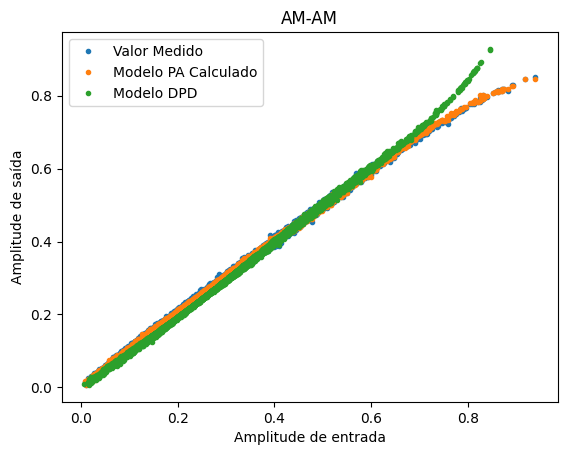

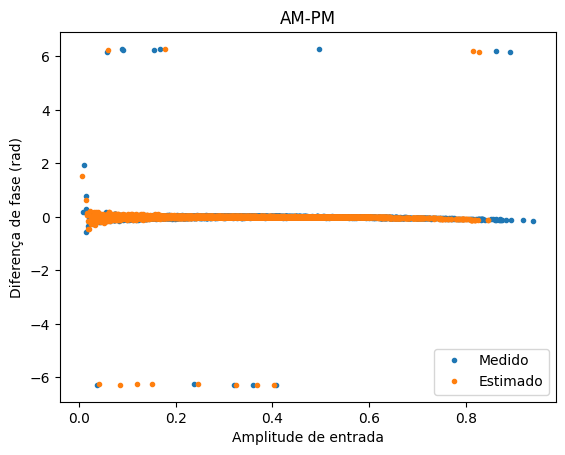

In [7]:
# saida estimada da cascata
predicted_val_PA_norm = mp_model(in_val_norm, coefficients_norm_pa, P, M)

predicted_val_DPD_norm = mp_model(predicted_val_PA_norm, coefficients_norm_DPD, P, M)

# Gráficos AM-AM e AM-PM
plt.figure()
plt.plot(np.abs(in_val_norm), np.abs(out_val_norm), '.', label='Valor Medido')
plt.plot(np.abs(in_val_norm.flatten()), np.abs(predicted_val_PA_norm.flatten()), '.', label='Modelo PA Calculado')
plt.plot(np.abs(predicted_val_PA_norm.flatten()), np.abs(predicted_val_DPD_norm.flatten()), '.', label='Modelo DPD')
# plt.xlim([0, 1.5])
# plt.ylim([0, 1.5])

plt.xlabel('Amplitude de entrada')
plt.ylabel('Amplitude de saída')
plt.title('AM-AM')
plt.legend()

plt.figure()
plt.plot(np.abs(in_val_norm), np.angle(out_val_norm).flatten() - np.angle(in_val_norm).flatten(), '.', label='Medido')
plt.plot(np.abs(predicted_val_PA_norm), np.angle(predicted_val_PA_norm).flatten() - np.angle(in_val_norm).flatten(), '.', label='Estimado')
# plt.plot(np.abs(predicted_val_PA[M:]), np.angle(predicted_val_DPD)-np.angle(predicted_val_PA[M:]), '.', label='Estimado')
plt.xlabel('Amplitude de entrada')
plt.ylabel('Diferença de fase (rad)')
plt.title('AM-PM')
plt.legend()
plt.show()

In [8]:

p_bits = 10
# normalização
in_val_fixed = np.round(in_val_norm * (2 ** p_bits)) 
out_val_fixed = np.round(out_val_norm * (2 ** p_bits))
in_ext_fixed = np.round(in_ext_norm * (2 ** p_bits)) 
out_ext_fixed = np.round(out_ext_norm * (2 ** p_bits))


def readeq_int(val, scale):
    return np.floor(val / scale) 

def MultiplicadorMatrizes(coefficients, XX, precision):
    # Aceita qualquer shape: (N,), (N,1), (1,N) — normaliza para 1D
    coefficients = np.array(coefficients)

    scale = 2 ** precision
    max_value = 0
    coef_q = np.round(coefficients * scale)  # quantizar coeficientes

    result = np.zeros((XX.shape[0], XX.shape[1]), dtype=np.complex128)

    for i in range(XX.shape[0]):
        for j in range(XX.shape[1]):
            A = np.real(coef_q[j])  # coef real  — índice j direto, sem [j,0]
            B = np.imag(coef_q[j])  # coef imag
            C = np.real(XX[i, j])   # XX real
            D = np.imag(XX[i, j])   #

            readequated_real = readeq_int(A * C, scale) - readeq_int(B * D, scale)
            readequated_imag = readeq_int(A * D, scale) + readeq_int(B * C, scale)

            max_value = max(max_value, abs(readequated_real), abs(readequated_imag))

            result[i, j] = complex(readequated_real, readequated_imag)

    soma_filas = np.sum(result, axis=1).reshape(-1, 1)
    extra_bits = np.ceil(np.log2(max_value + 1)) if max_value > 0 else 0

    return soma_filas, extra_bits


def mp_int(P, M, xn, bits):
    L = xn.shape
    xn = xn.flatten()

    scale = 2 ** bits
    
    XX = np.zeros((L[0] - M, P * (M+1)), dtype=np.complex128)

    for l in range(M, L[0]):  # 🔴 começa em M (igual mp)
        for m in range(0, M+1):
            A = np.real(xn[l - m])
            B = np.imag(xn[l - m])

            # |x|^2 com reescala
            modulo_square = readeq_int(A**2, scale) + readeq_int(B**2, scale)

            # começa com x (p = 1)
            real_base = A
            imag_base = B

            for p in range(1, P+1):

                if p == 1:
                    real_part = real_base
                    imag_part = imag_base
                else:
                    # acumula potência: x * |x|^(2p-2)
                    real_base = readeq_int(real_base * modulo_square, scale)
                    imag_base = readeq_int(imag_base * modulo_square, scale)

                    real_part = real_base
                    imag_part = imag_base

                # preserva sinal (igual seu original)
                real_part = modulo_preservando_sinal(real_part, 2**bits)
                imag_part = modulo_preservando_sinal(imag_part, 2**bits)

                # ✅ NOVA ORDEM (compatível com mp_model)
                col = m * P + (p - 1)

                XX[l - M, col] = complex(real_part, imag_part)

    return XX



# modelo do PA
XX_val_PA = mp_int(P, M, in_val_fixed, p_bits)
predicted_val_fixed_PA, e_bits = MultiplicadorMatrizes(coefficients_norm_pa, XX_val_PA, p_bits)

# modelo do DPD
XX_val_DPD = mp_int(P, M, in_val_fixed, p_bits)
predicted_val_fixed_DPD, e_bits = MultiplicadorMatrizes(coefficients_norm_DPD, XX_val_DPD, p_bits)


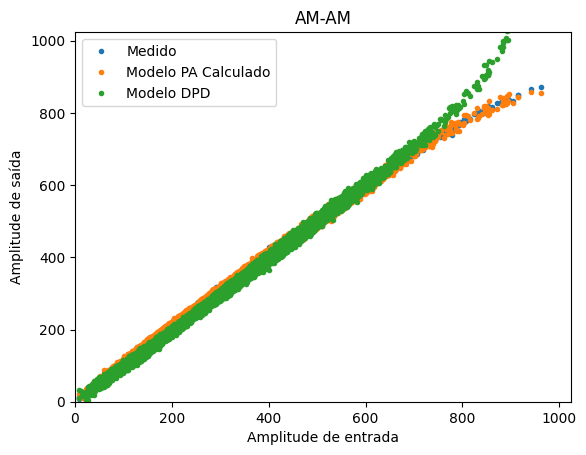

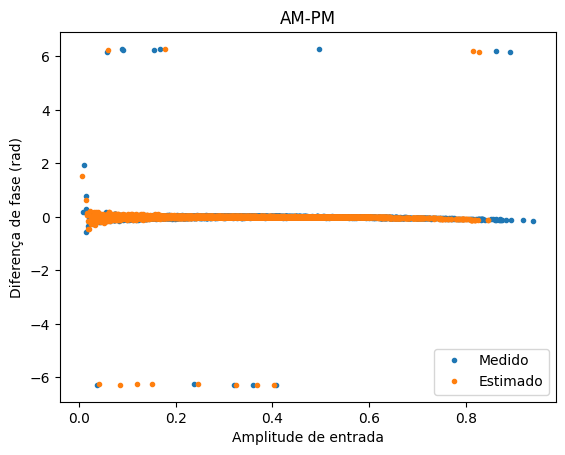

In [9]:
# Gráficos AM-AM e AM-PM
fig, ax = plt.subplots()
ax.plot(np.abs(in_val_fixed),np.abs(out_val_fixed), '.', label='Medido')
ax.plot(np.abs(in_val_fixed[M:]),np.abs(predicted_val_fixed_PA), '.', label='Modelo PA Calculado')
ax.plot(np.abs(in_val_fixed[M:]),np.abs(predicted_val_fixed_DPD), '.', label='Modelo DPD')
ax.set_xlim([0, 2 ** p_bits])
ax.set_ylim([0, 2 ** p_bits])

plt.xlabel('Amplitude de entrada')
plt.ylabel('Amplitude de saída')
plt.title('AM-AM')
plt.legend()

plt.figure()
plt.plot(np.abs(in_val_norm), np.angle(out_val_norm).flatten() - np.angle(in_val_norm).flatten(), '.', label='Medido')
plt.plot(np.abs(predicted_val_PA_norm), np.angle(predicted_val_PA_norm).flatten() - np.angle(in_val_norm).flatten(), '.', label='Estimado')
# plt.plot(np.abs(predicted_val_PA[M:]), np.angle(predicted_val_DPD)-np.angle(predicted_val_PA[M:]), '.', label='Estimado')
plt.xlabel('Amplitude de entrada')
plt.ylabel('Diferença de fase (rad)')
plt.title('AM-PM')
plt.legend()
plt.show()

In [10]:
init_msg = '''
onerror {resume}
quietly WaveActivateNextPane {} 0
add wave -noupdate /dpd/reset
add wave -noupdate /dpd/clk
add wave -noupdate /dpd/UR
add wave -noupdate /dpd/UI
add wave -noupdate /dpd/UR_out
add wave -noupdate /dpd/UI_out
add wave -noupdate /dpd/U_signal_out
add wave -noupdate /dpd/U_signal_in
add wave -noupdate /dpd/power_matrix
add wave -noupdate /dpd/confusion_matrix
add wave -noupdate /dpd/multiplic
add wave -noupdate /dpd/sum
TreeUpdate [SetDefaultTree]
WaveRestoreCursors {{Cursor 1} {0 ps} 0}
quietly wave cursor active 0
configure wave -namecolwidth 150
configure wave -valuecolwidth 100
configure wave -justifyvalue left
configure wave -signalnamewidth 0
configure wave -snapdistance 10
configure wave -datasetprefix 0
configure wave -rowmargin 4
configure wave -childrowmargin 2
configure wave -gridoffset 0
configure wave -gridperiod 1
configure wave -griddelta 40
configure wave -timeline 0
configure wave -timelineunits ps
update
WaveRestoreZoom {0 ps} {1 ns}

force -freeze sim:/dpd/reset 1 0
force -freeze sim:/dpd/UR 000000000 0
force -freeze sim:/dpd/UI 000000000 0
force -freeze sim:/dpd/clk 1 0, 0 {50 ps} -r 100
run 200 ps
force -freeze sim:/dpd/reset 0 0
run 100 ps
'''

data_value = '''
run 100 ps
force -freeze sim:/dpd/UR {val_rel} 0
force -freeze sim:/dpd/UI {val_imag} 0'''

inteiro_para_binario = lambda x, p_bits: format(x if x >= 0 else (1 << p_bits + 1) + x, f'0{p_bits + 1}b')

inv_val = in_val_fixed

message = init_msg
for value in inv_val[:50].flatten():
    message += data_value.format(
        val_rel  = inteiro_para_binario(int(np.real(value)), p_bits),
        val_imag = inteiro_para_binario(int(np.imag(value)), p_bits)
    )
    
with open('VHDL/macro.do', 'w') as file_do:
    file_do.write(message)


In [11]:
init_msg = '''
onerror {resume}
quietly WaveActivateNextPane {} 0
add wave -noupdate /dpd/reset
add wave -noupdate /dpd/clk
add wave -noupdate /dpd/UR
add wave -noupdate /dpd/UI
add wave -noupdate /dpd/UR_out
add wave -noupdate /dpd/UI_out
add wave -noupdate /dpd/U_signal_out
add wave -noupdate /dpd/U_signal_in
add wave -noupdate /dpd/power_matrix
add wave -noupdate /dpd/confusion_matrix
add wave -noupdate /dpd/multiplic
add wave -noupdate /dpd/sum
TreeUpdate [SetDefaultTree]
WaveRestoreCursors {{Cursor 1} {0 ps} 0}
quietly wave cursor active 0
configure wave -namecolwidth 150
configure wave -valuecolwidth 100
configure wave -justifyvalue left
configure wave -signalnamewidth 0
configure wave -snapdistance 10
configure wave -datasetprefix 0
configure wave -rowmargin 4
configure wave -childrowmargin 2
configure wave -gridoffset 0
configure wave -gridperiod 1
configure wave -griddelta 40
configure wave -timeline 0
configure wave -timelineunits ps
update
WaveRestoreZoom {0 ps} {1 ns}

force -freeze sim:/dpd/reset 1 0
force -freeze sim:/dpd/UR 000000000 0
force -freeze sim:/dpd/UI 000000000 0
force -freeze sim:/dpd/clk 1 0, 0 {50 ps} -r 100
run 200 ps
force -freeze sim:/dpd/reset 0 0
run 100 ps
'''

data_value = '''
run 100 ps
force -freeze sim:/dpd/UR {val_rel} 0
force -freeze sim:/dpd/UI {val_imag} 0'''

inteiro_para_binario = lambda x, p_bits: format(x if x >= 0 else (1 << p_bits + 1) + x, f'0{p_bits + 1}b')

inv_val = in_val_fixed

message = init_msg
message = init_msg
for value in inv_val[:50]:
    v = value.item() if hasattr(value, 'item') else complex(value)
    message += data_value.format(
        val_rel  = inteiro_para_binario(int(np.real(v)), p_bits),
        val_imag = inteiro_para_binario(int(np.imag(v)), p_bits)
    )
with open('VHDL/macro.do', 'w') as file_do:
    file_do.write(message)

In [22]:
output_file = os.path.join("VHDL", "complex_constants.vhd")
complex_numbers = coefficients_norm_DPD * (2 ** p_bits)

# Reorganiza o vetor flat de coeficientes em matriz (n_signals_used x n_polygnos_degree)
# O vetor original tem shape (P*(M+1), 1), organizado como:
# [coef(p=1,m=0), coef(p=1,m=1), ..., coef(p=P,m=0), coef(p=P,m=1), ...]
# Reshape para (P, M+1) e transpõe para (M+1, P) = (n_signals_used, n_polygnos_degree)
n_signals_used    = M + 1
n_polygnos_degree = P
coef_matrix = complex_numbers.reshape(n_signals_used, n_polygnos_degree)  # shape: (n_signals_used, n_polygnos_degree)


vhdl_header = f"""\
  CONSTANT n_signals_used : INTEGER := {n_signals_used};
  CONSTANT n_polygnos_degree : INTEGER := {n_polygnos_degree};
  CONSTANT n_bits_resolution : INTEGER := {int(p_bits)} + 1;
  CONSTANT n_bits_overflow : INTEGER := {int(8)};
  CONSTANT max_value : INTEGER := 2 ** (n_bits_resolution - 1) - 1;
  CONSTANT max_value_overflow : INTEGER := 2 ** (n_bits_resolution + n_bits_overflow - 1) - 1;
  SUBTYPE limited_integer IS INTEGER RANGE -max_value TO max_value;
  SUBTYPE overflow_integer IS INTEGER RANGE -max_value_overflow TO max_value_overflow;
  TYPE complex_number IS RECORD
    reall : limited_integer;
    imag : limited_integer;
  END RECORD;
  TYPE complex_number_overflow IS RECORD
    reall : overflow_integer;
    imag : overflow_integer;
  END RECORD;
  TYPE complex_coefficients IS ARRAY (0 TO n_signals_used - 1, 0 TO n_polygnos_degree - 1) OF complex_number;
  CONSTANT coefficients : complex_coefficients := (
"""

vhdl_footer = """\
  );
"""


# Converte um número complexo em string VHDL
complex_to_vhdl_string = lambda c: f"(reall => {int(np.round(np.real(c)))}, imag => {int(np.round(np.imag(c)))})"
# Gera as linhas da matriz 2D: cada linha i é uma row do agregado VHDL
rows = []
for i in range(n_signals_used):
    row_elements = ", ".join([complex_to_vhdl_string(coef_matrix[i, j]) for j in range(n_polygnos_degree)])
    comma = "," if i < n_signals_used - 1 else ""
    rows.append(f"    ({row_elements}){comma}")

vhdl_content = vhdl_header
vhdl_content += "\n".join(rows)
vhdl_content += "\n" + vhdl_footer

with open(output_file, "w") as f:
    f.write(vhdl_content)

print(f"Arquivo VHDL '{output_file}' gerado com sucesso!")

Arquivo VHDL 'VHDL/complex_constants.vhd' gerado com sucesso!


In [24]:
init_msg = '''--------------------------------------------------------------------------------
LIBRARY ieee;
USE ieee.std_logic_1164.ALL;
USE IEEE.NUMERIC_STD.ALL;
USE ieee.std_logic_textio.ALL;
USE std.textio.ALL;
LIBRARY work;
USE work.functions.ALL;

ENTITY tb IS
END tb;
 
ARCHITECTURE behavior OF tb IS 
    -- Component Declaration for the Unit Under Test (UUT)
    COMPONENT dpd
        PORT (
            reset : IN STD_LOGIC;
            clk : IN STD_LOGIC;
            UR : IN STD_LOGIC_VECTOR(n_bits_resolution - 1 DOWNTO 0);
            UI : IN STD_LOGIC_VECTOR(n_bits_resolution - 1 DOWNTO 0);
            UR_out : OUT STD_LOGIC_VECTOR(n_bits_resolution - 1 DOWNTO 0);
            UI_out : OUT STD_LOGIC_VECTOR(n_bits_resolution - 1 DOWNTO 0)
        );
    END COMPONENT;

    -- Signals for connecting to UUT
    SIGNAL reset : STD_LOGIC := '0';
    SIGNAL clk : STD_LOGIC := '0';
    SIGNAL UR : STD_LOGIC_VECTOR(n_bits_resolution - 1 DOWNTO 0) := (OTHERS => '0');
    SIGNAL UI : STD_LOGIC_VECTOR(n_bits_resolution - 1 DOWNTO 0) := (OTHERS => '0');
    SIGNAL UR_out : STD_LOGIC_VECTOR(n_bits_resolution - 1 DOWNTO 0) := (OTHERS => '0');
    SIGNAL UI_out : STD_LOGIC_VECTOR(n_bits_resolution - 1 DOWNTO 0);

    -- Clock period definition
    CONSTANT clk_period : TIME := 16 ns;
    FILE output_file : TEXT OPEN WRITE_MODE IS "simulation_output.txt";
 
BEGIN
 
	-- Instantiate the Unit Under Test (UUT)
   uut: DPD PORT MAP (
          reset => reset,
          clk => clk,
          UR => UR,
          UI => UI,
          UR_out => UR_out,
          UI_out => UI_out
        );

   -- Clock process definitions
   clk_process :process
   begin
		clk <= '0';
		wait for clk_period/2;
		clk <= '1';
		wait for clk_period/2;
   end process;
 
    write_output : PROCESS(clk)
        VARIABLE line_buffer : LINE;
        VARIABLE data : INTEGER;
    BEGIN
        IF reset = '0' and rising_edge(clk) THEN
            WRITE(line_buffer, to_integer(signed(UR_out)));
            WRITE(line_buffer, STRING'(","));
            WRITE(line_buffer, to_integer(signed(UI_out)));
            WRITE(line_buffer, STRING'("j"));
            WRITELINE(output_file, line_buffer);
        END IF;
    END PROCESS;

      -- in process
   calc_proc: process
   begin		
      reset <= '1';
      wait for 2 * clk_period;	
      reset <= '0';
      WAIT FOR clk_period;
      {values}

      wait;
   end process;
    
END;
'''

data_value = '''
UR <= "{val_rel}";
UI <= "{val_imag}";
WAIT FOR clk_period;'''

inteiro_para_binario = lambda x, p_bits: format(x if x >= 0 else (1 << p_bits + 1) + x, f'0{p_bits + 1}b')

inv_val = in_val_fixed

message = ''
for value in inv_val.flatten():
    message += data_value.format(
        val_rel  = inteiro_para_binario(int(np.real(value)), p_bits),
        val_imag = inteiro_para_binario(int(np.imag(value)), p_bits)
    )
tb_file = os.path.join("VHDL","tb_main.vhd")

# Escrevendo o conteúdo no arquivo
with open(tb_file, "w") as f:
    f.write(init_msg.format(values = message))

print(f"Arquivo VHDL '{tb_file}' gerado com sucesso!")


Arquivo VHDL 'VHDL/tb_main.vhd' gerado com sucesso!


In [19]:
import pandas as pd

out_signal = pd.read_csv('simulation_output.txt')
out_signal = out_signal.astype(complex)
out_sintesi = (out_signal['0'] + out_signal['0j']).values.reshape(-1, 1)
out_signal = np.delete(out_signal, np.where(out_signal == 0.0+0.0j))

for i in range(len( out_sintesi)):
    if out_sintesi[i] == predicted_val_fixed_DPD[0]:
        out_sintesi= out_sintesi[i:]
        break


predicted_val_fixed_DPD




array([[ 116.-339.j],
       [ 108.-286.j],
       [  92.-214.j],
       ...,
       [-446. +16.j],
       [-352.-118.j],
       [-223.-251.j]], shape=(4498, 1))

/tmp/ipykernel_20059/598543651.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


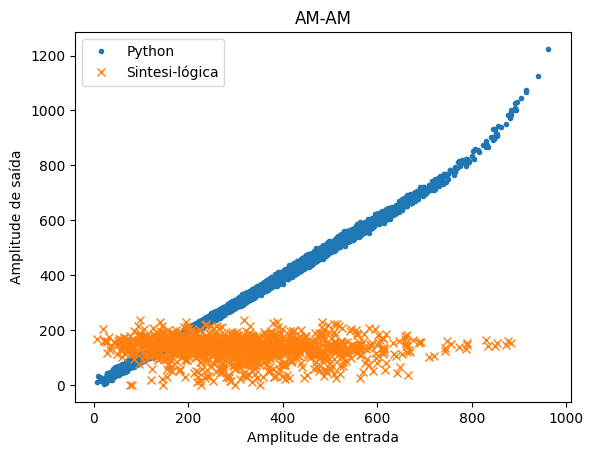

In [17]:
nmse_calculo_sim = lambda predicted_val, data_out:10 * np.log10(np.mean(np.abs(data_out - predicted_val) ** 2) / np.mean(np.abs(data_out) ** 2))

predicted_val_fixed_pre = predicted_val_fixed_DPD.reshape(-1, 1)
in_val_fixed = np.array(in_val_fixed)

# out_sintesi = out_sintesi[100:]
nmse_sintese = nmse_calculo_sim(predicted_val_fixed_pre[:out_sintesi.shape[0]], out_sintesi)
fig, ax = plt.subplots()
ax.plot(np.abs(in_val_fixed[M:]), np.abs(predicted_val_fixed_DPD), '.', label='Python')
ax.plot(np.abs(in_val_fixed[M:M + len(out_sintesi)]), np.abs(out_sintesi), 'x', label='Sintesi-lógica')
# ax.set_xlim([0, 2 ** p_bits])
# ax.set_ylim([0, 2 ** p_bits])

ax.set_xlabel('Amplitude de entrada')
ax.set_ylabel('Amplitude de saída')
ax.set_title('AM-AM')
ax.legend()
fig.show()

0.0005511379508573645


/tmp/ipykernel_20059/1296327782.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


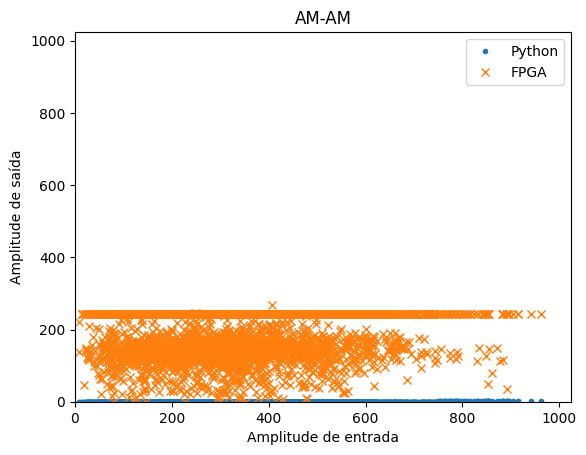

In [18]:
import pandas as pd

out_signal = pd.read_csv('simulation_fpga.txt')
out_signal = out_signal.astype(complex)
out_fpga = (out_signal['0'] + out_signal['0j']).values.reshape(-1, 1)
# out_fpga = np.delete(out_fpga, np.where(out_fpga == 0+0j))
out_fpga =out_fpga[8:]

for i in range(len( out_fpga)):
    if out_fpga[i] == predicted_val_DPD[0]:
        out_fpga= out_fpga[i:]
        break

nmse_fpga = nmse_calculo_sim(predicted_val_DPD[:out_fpga.shape[0]], out_fpga)


predicted_val_fixed_pre = predicted_val_DPD.reshape(-1, 1)
in_val_fixed = np.array(in_val_fixed)

out_fpga = out_fpga[:predicted_val_fixed_pre.shape[0]]
nmse_fpga = nmse_calculo(predicted_val_fixed_pre[:len(out_fpga)], out_fpga, 0)
print(nmse_fpga)

fig, ax = plt.subplots()
ax.plot(np.abs(in_val_fixed), np.abs(predicted_val_fixed_pre), '.', label='Python')
ax.plot(np.abs(in_val_fixed[M:len(out_fpga) + M]), np.abs(out_fpga[:len(in_val_fixed)]), 'x', label='FPGA')
ax.set_xlim([0, 2 ** p_bits])
ax.set_ylim([0, 2 ** p_bits])

ax.set_xlabel('Amplitude de entrada')
ax.set_ylabel('Amplitude de saída')
ax.set_title('AM-AM')
ax.legend()
fig.show()